In [2]:
import os
import tempfile
from pathlib import Path

#import pooch
import scanpy as sc
import scvi
import torch

/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  warn(f"Failed to load image Python extension: {e}")
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.1.2


In [102]:
sc.settings.figdir = "../result/intergrate/"

In [4]:
sc.set_figure_params(figsize=(4, 4), frameon=False)
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor" : "w"}
%config InlineBackend.figure_format="retina"

In [6]:
adata = sc.read("../process/framework/obj/combined_E12_E14_signc_sceasy.h5ad")
adata

AnnData object with n_obs × n_vars = 42042 × 297386
    obs: 'nCount_ATAC', 'nFeature_ATAC', 'nCount_peaks', 'nFeature_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'nucleosome_group', 'TSS.enrichment', 'TSS.percentile', 'high.tss', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'pct_reads_in_peaks', 'blacklist_ratio', 'n_fragment', 'frac_dup', 'scDblFinderScore', 'peaks_snn_res.0.8', 'seurat_clusters', 'nCount_RNA', 'nFeature_RNA', 'predicted.id', 'prediction.score.pe4', 'prediction.score.pe2', 'prediction.score.pe3', 'prediction.score.pe1', 'prediction.score.pe6', 'prediction.score.pe11', 'prediction.score.pe5', 'prediction.score.pe10', 'prediction.score.pe8', 'predictio

In [7]:
(adata.X == 1).sum()

261420050

In [8]:
(adata.X == 2).sum()

38221180

In [12]:
(adata.X == 3).sum()

9529840

In [13]:
(adata.X == 4).sum()

3180074

In [9]:
scvi.data.reads_to_fragments(adata)

In [10]:
(adata.layers["fragments"] == 1).sum()

299641230

In [11]:
(adata.layers["fragments"] == 2).sum()

12709914

In [14]:
print("# regions before filtering:", adata.shape[-1])

# compute the threshold: 5% of the cells
min_cells = int(adata.shape[0] * 0.05)
# in-place filtering of regions
sc.pp.filter_genes(adata, min_cells=min_cells)

print("# regions after filtering:", adata.shape[-1])

# regions before filtering: 297386
# regions after filtering: 32923


In [15]:
scvi.external.POISSONVI.setup_anndata(adata, layer="fragments",batch_key="batch")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
model = scvi.external.POISSONVI(adata)
model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 8/500:   1%|▏         | 7/500 [17:05<20:10:38, 147.34s/it, v_num=1, train_loss_step=1.17e+4, train_loss_epoch=1.16e+4]

In [ ]:
model_dir = os.path.join("../process/integration/peakvi", "peakPossion_epoch")
model.save(model_dir, overwrite=True)

In [18]:
model

PoissonVI Model with the following params: 
n_hidden: None, n_latent: None, n_layers: 2, dropout_rate: 0.1, peak_likelihood: poisson, latent_distribution: 
normal
Training status: Trained

In [19]:
POISSONVI_LATENT_KEY = "X_poissonvi"

latent = model.get_latent_representation()
adata.obsm[POISSONVI_LATENT_KEY] = latent
latent.shape

(42042, 13)

In [20]:
POISSONVI_CLUSTERS_KEY = "clusters_poissonvi"

# compute the k-nearest-neighbor graph that is used in both clustering and umap algorithms
sc.pp.neighbors(adata, use_rep=POISSONVI_LATENT_KEY)
# compute the umap
sc.tl.umap(adata, min_dist=0.2)
# cluster the space (we use a lower resolution to get fewer clusters than the default)
sc.tl.leiden(adata, key_added=POISSONVI_CLUSTERS_KEY, resolution=0.2)

/tmp/ipykernel_1387814/2628586055.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=POISSONVI_CLUSTERS_KEY, resolution=0.2)


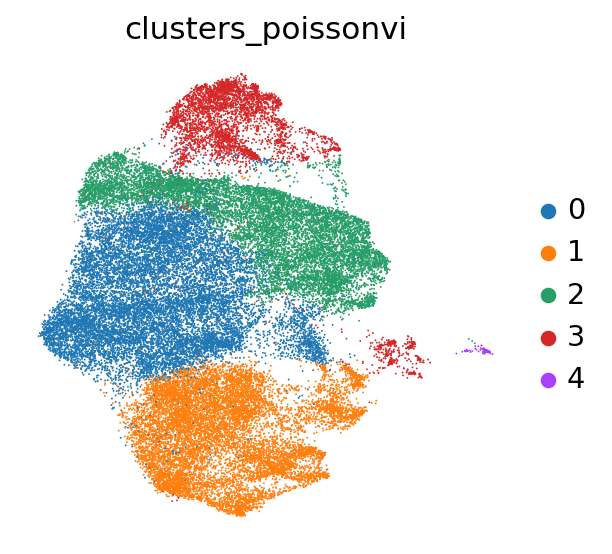

In [21]:
sc.pl.umap(adata, color=POISSONVI_CLUSTERS_KEY)

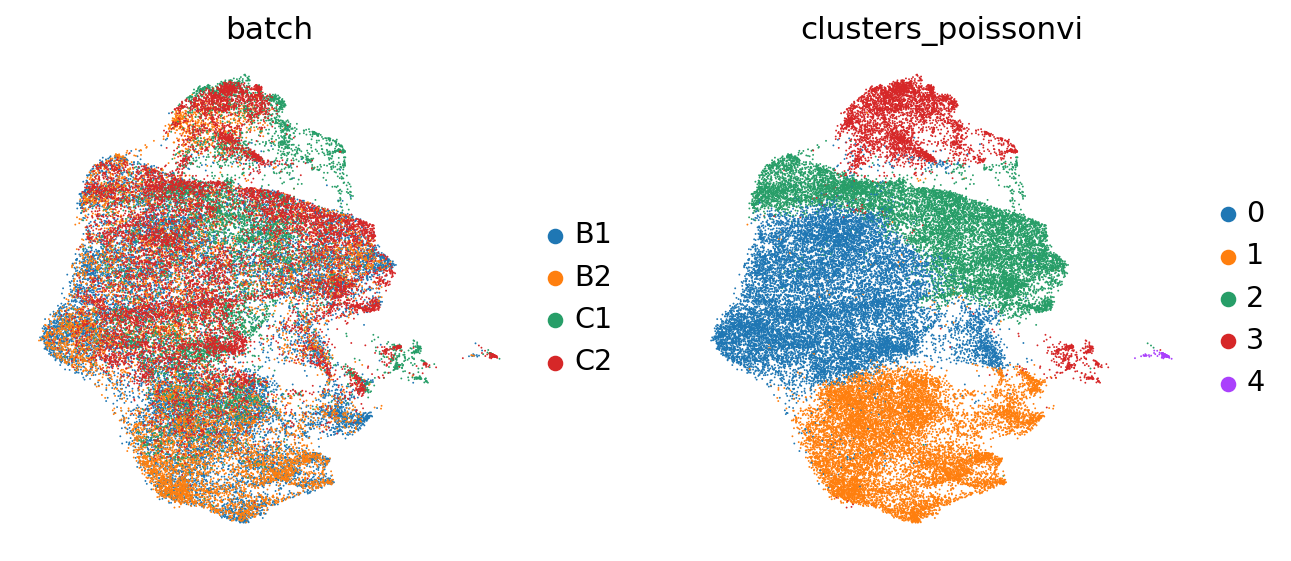

In [103]:
sc.pl.umap(adata, color=["batch",POISSONVI_CLUSTERS_KEY],save="_possion_umap_batch")

In [26]:
import pandas as pd
possionvi_df = pd.DataFrame(adata.obsm[POISSONVI_LATENT_KEY])
possionvi_df.index = adata.obs_names
possionvi_df.to_csv("../process/framework/reduction/7.17_combined_possionvi.csv")

In [27]:
umap_df = pd.DataFrame(adata.obsm["X_umap"])
umap_df.index = adata.obs_names
umap_df.to_csv("../process/framework/reduction/7.17_possion_umap_full.csv")

In [33]:
pd.DataFrame(adata.obs["clusters_poissonvi"]).to_csv("../process/framework/cluster/combine_possionvi.csv")

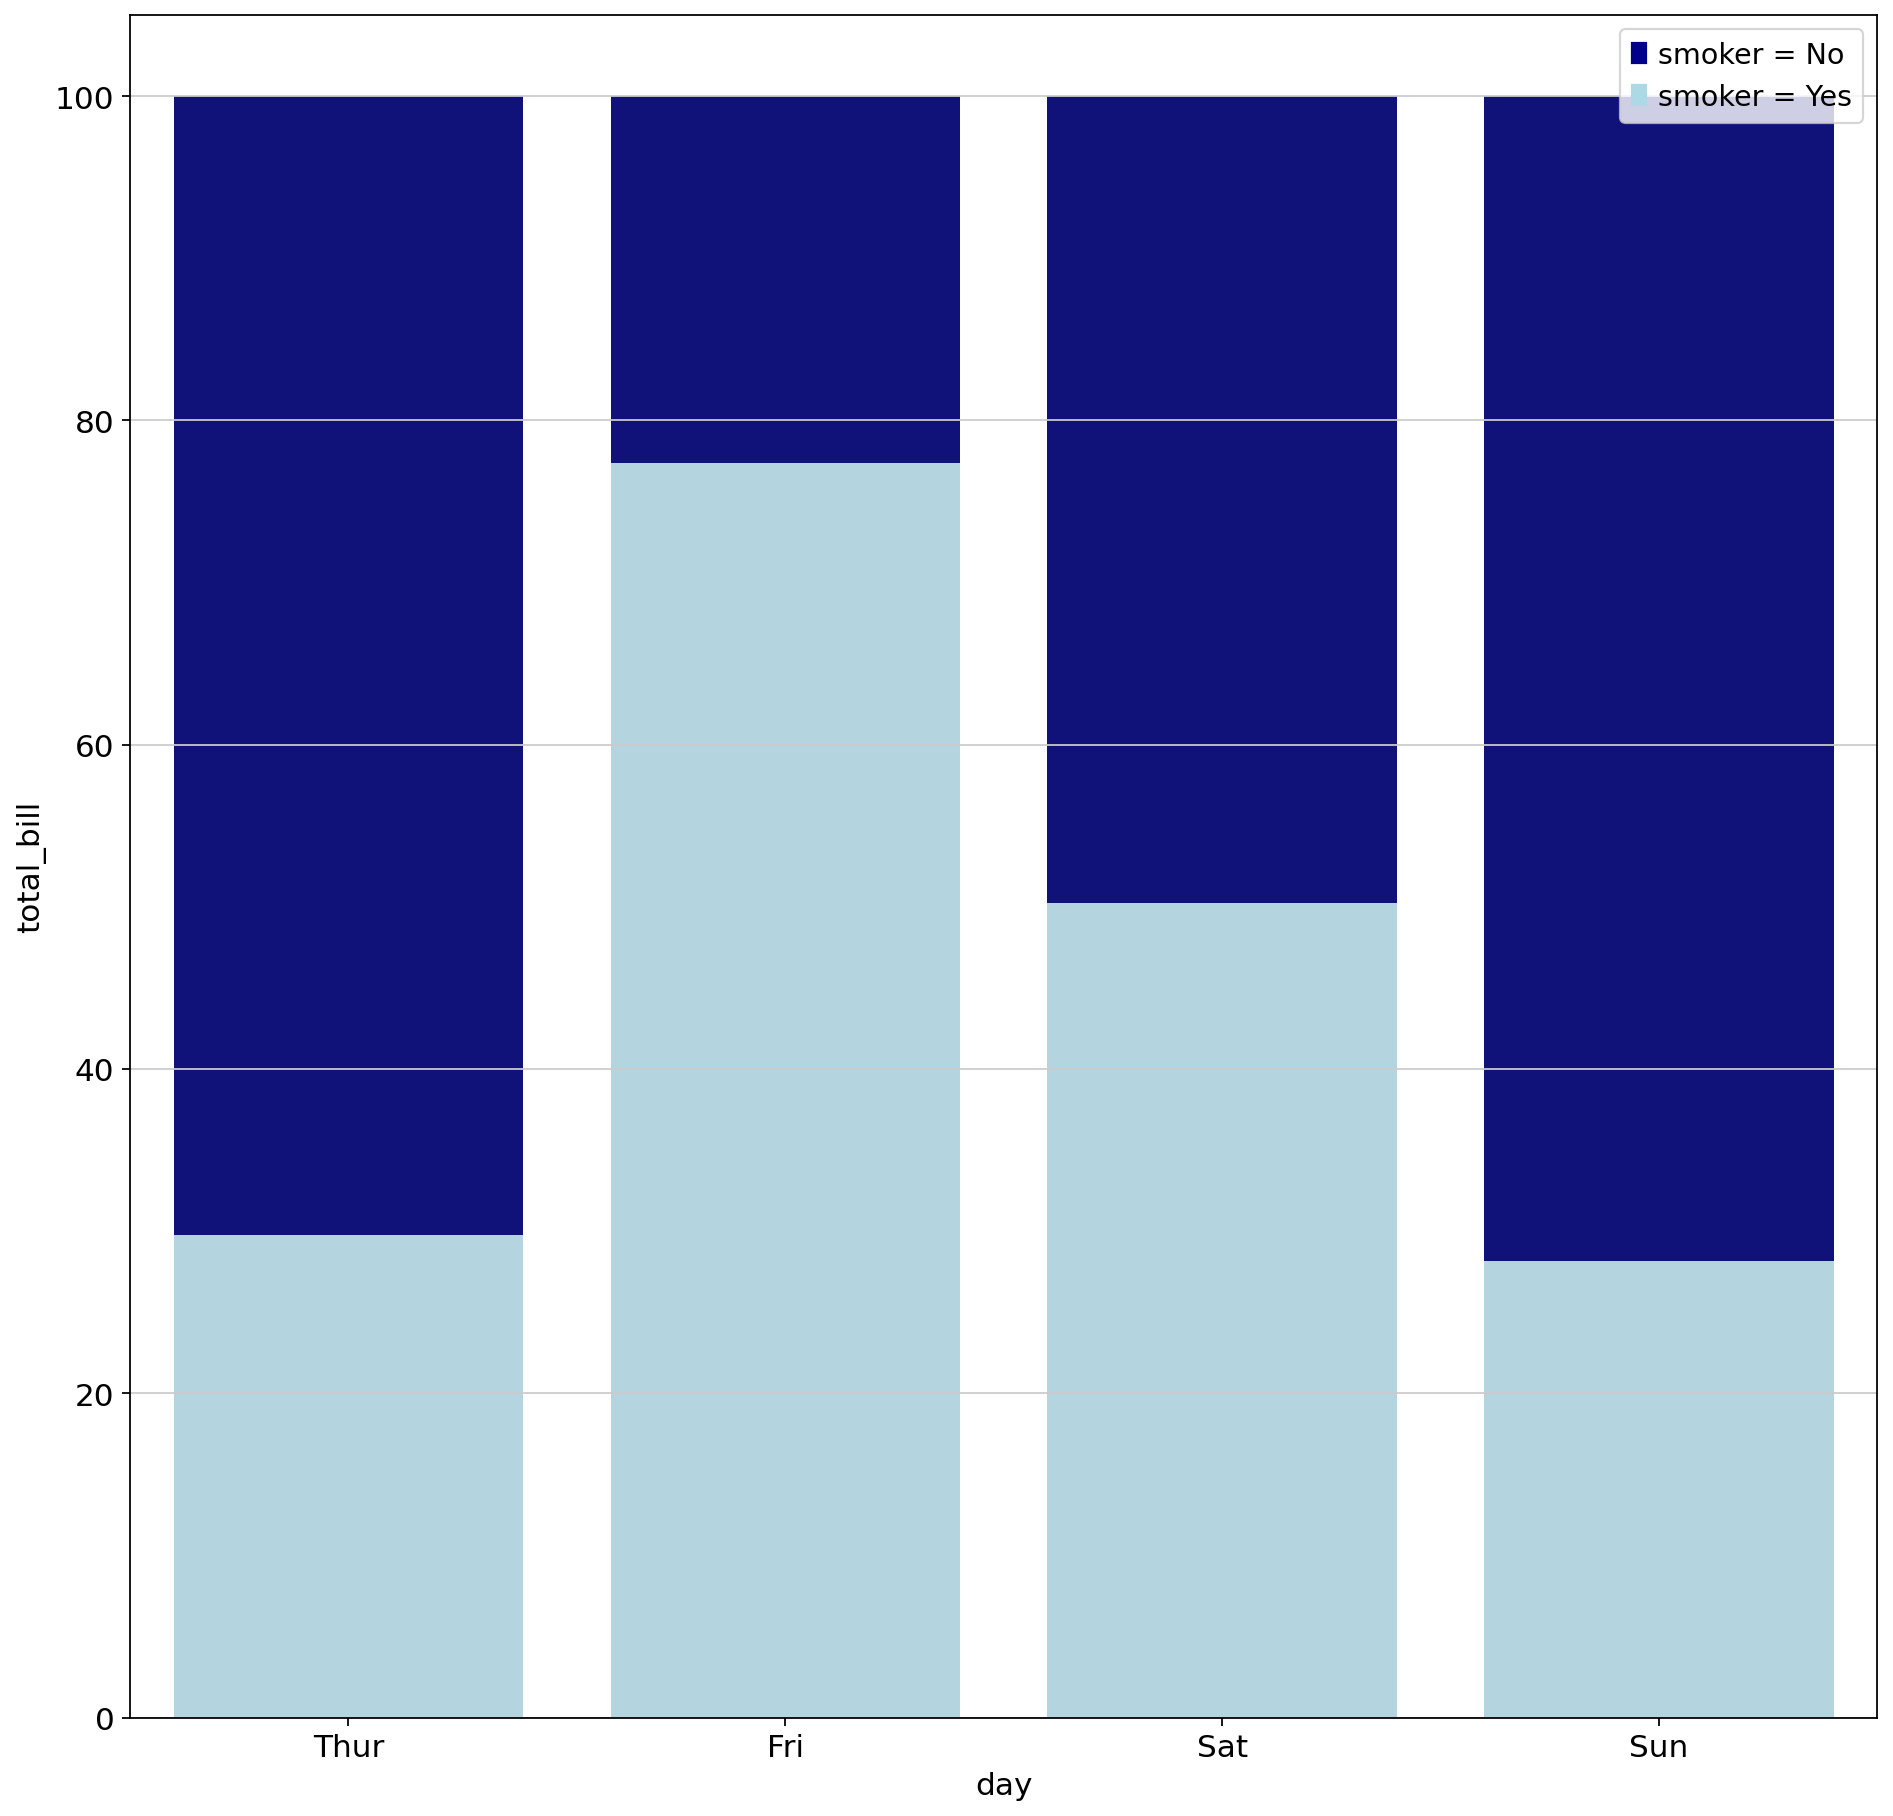

In [44]:
# import libraries
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# load dataset
tips = sns.load_dataset("tips")

# set the figure size
plt.figure(figsize=(14, 14))

# from raw value to percentage
total = tips.groupby('day')['total_bill'].sum().reset_index()
smoker = tips[tips.smoker=='Yes'].groupby('day')['total_bill'].sum().reset_index()
smoker['total_bill'] = [i / j * 100 for i,j in zip(smoker['total_bill'], total['total_bill'])]
total['total_bill'] = [i / j * 100 for i,j in zip(total['total_bill'], total['total_bill'])]

# bar chart 1 -> top bars (group of 'smoker=No')
bar1 = sns.barplot(x="day",  y="total_bill", data=total, color='darkblue')

# bar chart 2 -> bottom bars (group of 'smoker=Yes')
bar2 = sns.barplot(x="day", y="total_bill", data=smoker, color='lightblue')

# add legend
top_bar = mpatches.Patch(color='darkblue', label='smoker = No')
bottom_bar = mpatches.Patch(color='lightblue', label='smoker = Yes')
plt.legend(handles=[top_bar, bottom_bar])

# show the graph
plt.show()

In [49]:
grouped=adata.obs.groupby("clusters_poissonvi")["batch"].size().reset_index(name='count')

In [55]:
grouped2=adata.obs.groupby(["clusters_poissonvi","batch"]).size().reset_index(name='count')

In [94]:
df = grouped2
df_pivot = df.pivot_table(values='count', index='batch', columns='clusters_poissonvi', aggfunc='sum', fill_value=0)

In [95]:
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1) * 100


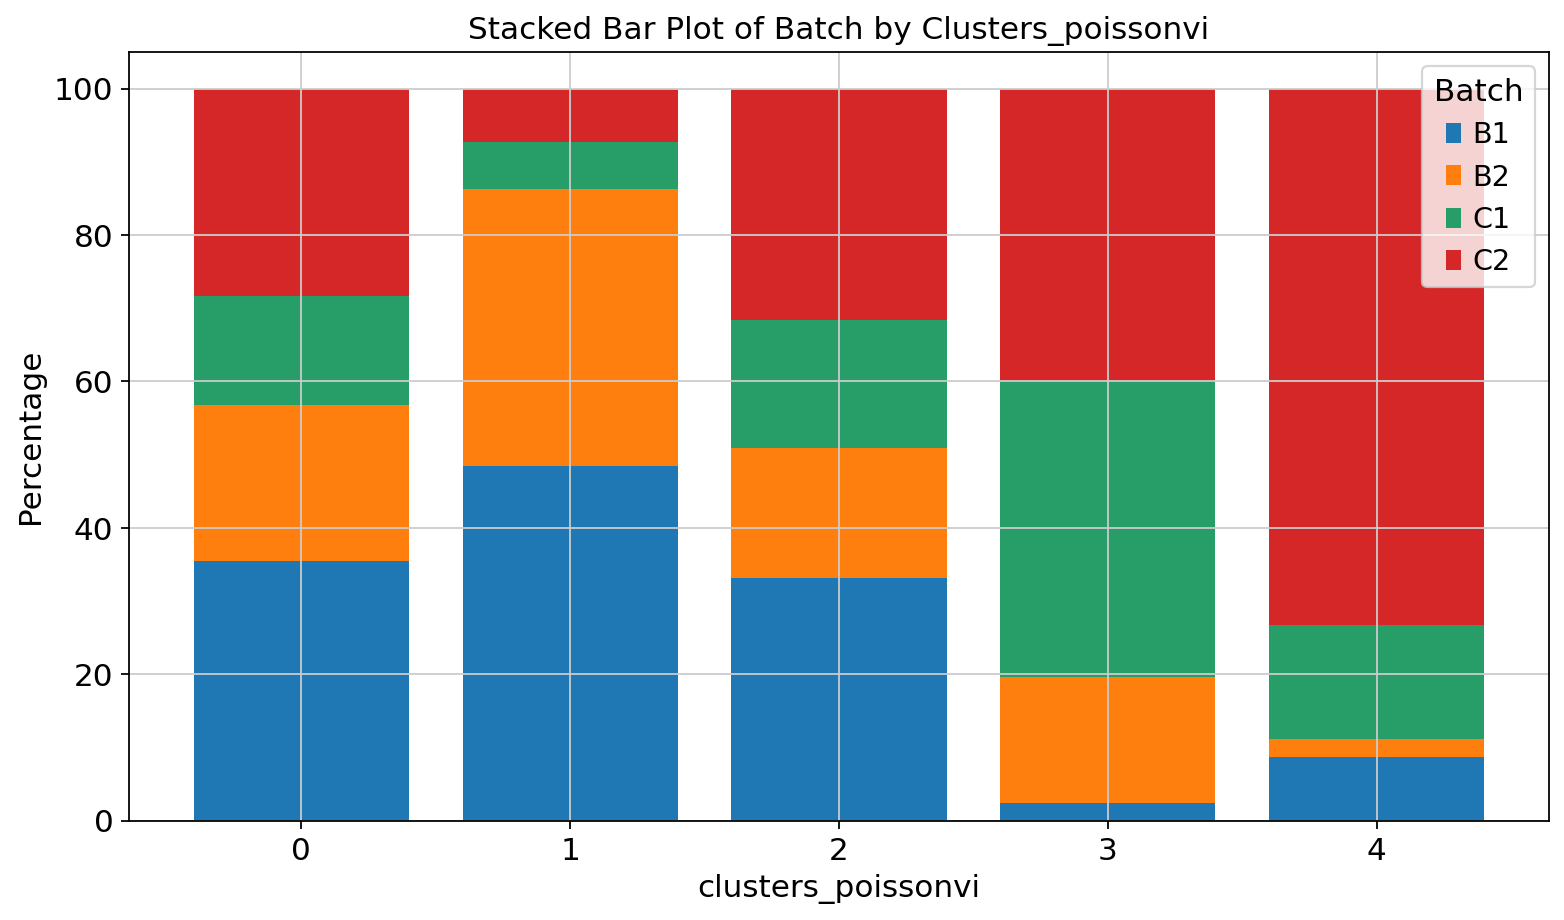

In [101]:
grouped2=adata.obs.groupby(["clusters_poissonvi","batch"]).size().reset_index(name='count')
df = grouped2
df_pivot = df.pivot_table(values='count', index='batch', columns='clusters_poissonvi', aggfunc='sum', fill_value=0)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1) * 100

df = df_pivot
# Plotting
plt.figure(figsize=(10, 6))

# Stacked bar plot
bottom = None
for batch in df.index:
    plt.bar(df.columns, df.loc[batch], bottom=bottom, label=batch)
    if bottom is None:
        bottom = df.loc[batch].values
    else:
        bottom += df.loc[batch].values

plt.xlabel('clusters_poissonvi')
plt.ylabel('Percentage')
plt.title('Stacked Bar Plot of Batch by Clusters_poissonvi')
plt.xticks(df.columns)
plt.legend(title='Batch')
plt.tight_layout()
plt.savefig("../result/intergrate/possionvi_integrate.pdf")
plt.show()

In [104]:
da_peaks_1 = model.differential_accessibility(
    adata, groupby=POISSONVI_CLUSTERS_KEY, group1="1", two_sided=False
)

DE...: 100%|██████████| 1/1 [02:46<00:00, 166.90s/it]


In [105]:
da_peaks_filt = da_peaks_1[(da_peaks_1.emp_prob1 >= 0.05)]

In [106]:
da_peaks_filt.head(10)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,emp_prob1,emp_prob2,emp_effect,is_de_fdr_0.05,comparison,group1,group2
chr13-72763087-72764133,0.9756,0.0244,3.688469,0.000041,0.000007,0.0,0.05,2.717000,2.708151,1.381930,-2.147926,8.186774,0.108740,0.028369,0.080371,True,1 vs Rest,1,Rest
chr13-72710863-72711739,0.9730,0.0270,3.584547,0.000054,0.000007,0.0,0.05,3.413886,3.418018,1.689662,-2.359035,8.245896,0.138412,0.024835,0.113577,True,1 vs Rest,1,Rest
chr12-70147893-70149338,0.9504,0.0496,2.952892,0.000036,0.000013,0.0,0.05,1.492107,1.518608,0.865135,-2.092785,4.737653,0.097943,0.062682,0.035261,True,1 vs Rest,1,Rest
chr5-91026949-91027959,0.9496,0.0504,2.936049,0.000042,0.000010,0.0,0.05,2.592845,2.558352,1.630075,-3.746915,7.646481,0.101173,0.036063,0.065110,True,1 vs Rest,1,Rest
chr11-50398241-50399156,0.9478,0.0522,2.899061,0.000028,0.000009,0.0,0.05,1.780533,1.807984,1.049859,-1.984995,5.466333,0.082044,0.042404,0.039640,True,1 vs Rest,1,Rest
chr6-113480302-113481398,0.9470,0.0530,2.883007,0.000038,0.000019,0.0,0.05,1.064359,1.042078,0.654378,-1.901871,4.183201,0.115882,0.097292,0.018590,True,1 vs Rest,1,Rest
chr6-52115904-52116976,0.9422,0.0578,2.791229,0.000044,0.000014,0.0,0.05,1.816963,1.854860,1.074805,-1.784283,5.553963,0.131185,0.072094,0.059091,True,1 vs Rest,1,Rest
chr16-31459622-31460714,0.9422,0.0578,2.791229,0.000045,0.000015,0.0,0.05,1.675951,1.620786,1.064759,-1.577925,5.518177,0.127274,0.080581,0.046693,True,1 vs Rest,1,Rest
chr9-45953074-45953943,0.9402,0.0598,2.755087,0.000029,0.000010,0.0,0.05,1.720666,1.715649,1.063864,-1.935410,5.885857,0.084169,0.050694,0.033476,True,1 vs Rest,1,Rest
chr1-191692396-191693709,0.9380,0.0620,2.716615,0.000052,0.000015,0.0,0.05,2.333774,2.199029,1.631090,-3.163039,8.025508,0.145043,0.060601,0.084442,True,1 vs Rest,1,Rest


In [108]:
da_peaks_filt

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,emp_prob1,emp_prob2,emp_effect,is_de_fdr_0.05,comparison,group1,group2
chr13-72763087-72764133,0.9756,0.0244,3.688469,0.000041,0.000007,0.0,0.05,2.717000,2.708151,1.381930,-2.147926,8.186774,0.108740,0.028369,0.080371,True,1 vs Rest,1,Rest
chr13-72710863-72711739,0.9730,0.0270,3.584547,0.000054,0.000007,0.0,0.05,3.413886,3.418018,1.689662,-2.359035,8.245896,0.138412,0.024835,0.113577,True,1 vs Rest,1,Rest
chr12-70147893-70149338,0.9504,0.0496,2.952892,0.000036,0.000013,0.0,0.05,1.492107,1.518608,0.865135,-2.092785,4.737653,0.097943,0.062682,0.035261,True,1 vs Rest,1,Rest
chr5-91026949-91027959,0.9496,0.0504,2.936049,0.000042,0.000010,0.0,0.05,2.592845,2.558352,1.630075,-3.746915,7.646481,0.101173,0.036063,0.065110,True,1 vs Rest,1,Rest
chr11-50398241-50399156,0.9478,0.0522,2.899061,0.000028,0.000009,0.0,0.05,1.780533,1.807984,1.049859,-1.984995,5.466333,0.082044,0.042404,0.039640,True,1 vs Rest,1,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr5-129585785-129586718,0.0672,0.9328,-2.630517,0.000023,0.000032,0.0,0.05,-0.477658,-0.475813,0.361995,-1.774080,1.073103,0.076263,0.168626,-0.092364,False,1 vs Rest,1,Rest
chr13-54371096-54372590,0.0660,0.9340,-2.649822,0.000033,0.000056,0.0,0.05,-0.746885,-0.740694,0.539431,-2.772078,1.312144,0.101003,0.267602,-0.166599,False,1 vs Rest,1,Rest
chr3-129199448-129200365,0.0602,0.9398,-2.747995,0.000028,0.000046,0.0,0.05,-0.689871,-0.701395,0.467900,-2.163693,1.664416,0.085530,0.211063,-0.125534,False,1 vs Rest,1,Rest
chr6-108212554-108213421,0.0534,0.9466,-2.875066,0.000032,0.000053,0.0,0.05,-0.737693,-0.757799,0.469958,-2.526505,1.130907,0.096497,0.254921,-0.158424,False,1 vs Rest,1,Rest


In [109]:
!mkdir ../process/differential_peak

In [110]:
da_peaks_filt.to_csv("../process/differential_peak/7.18_possion_vi_cluster1.csv")

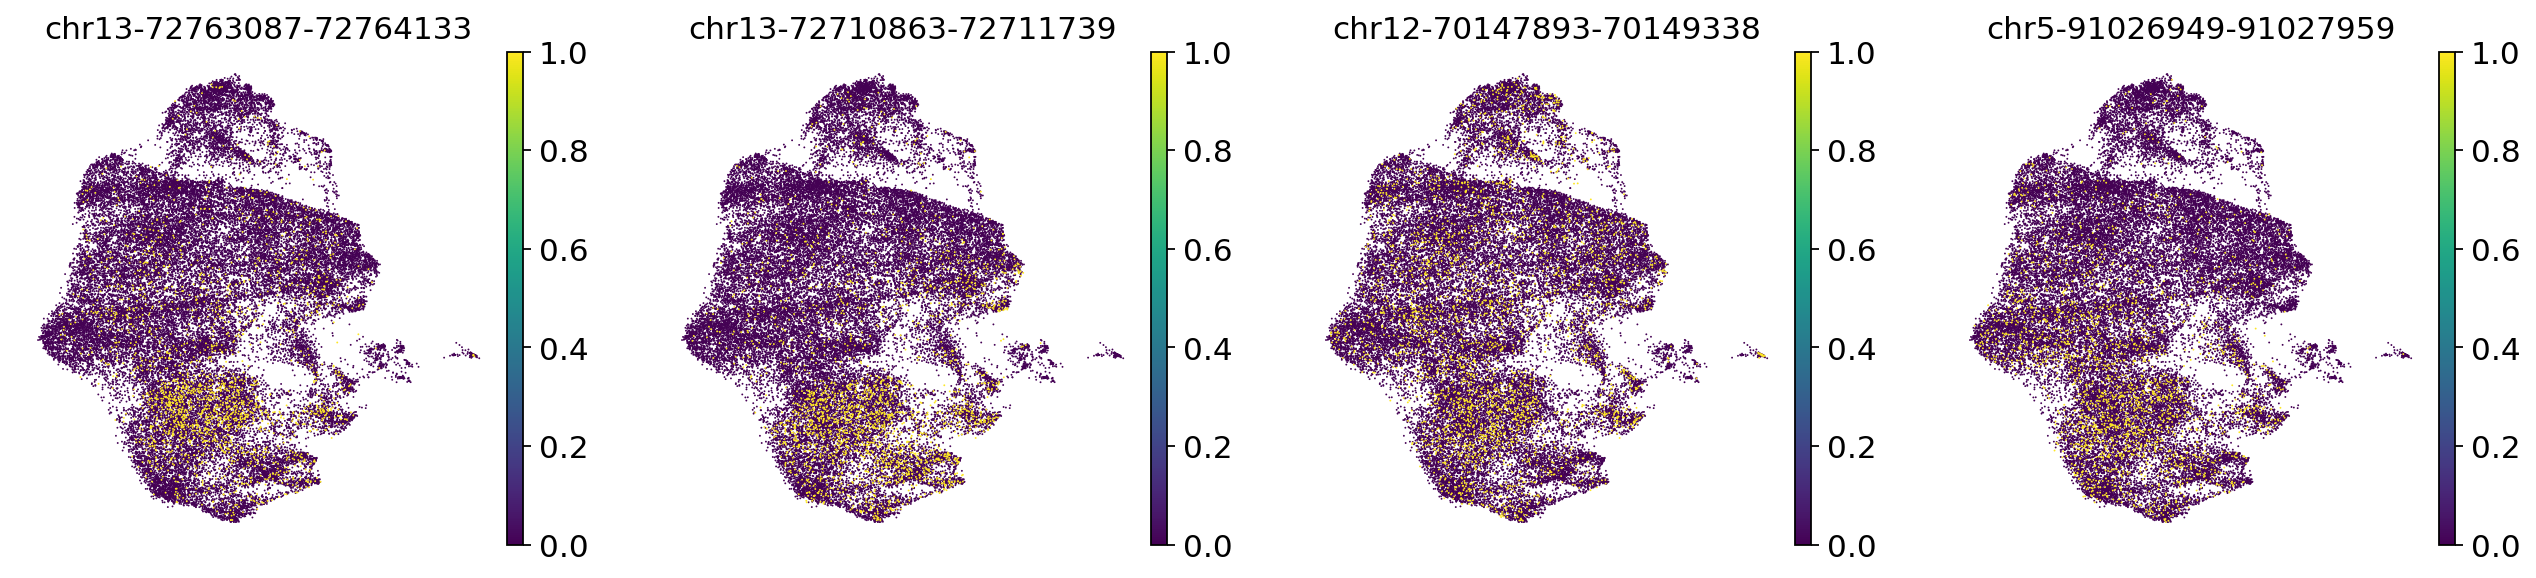

In [107]:
sc.pl.umap(adata, color=da_peaks_filt.index[:4], layer="fragments", vmax="p99.0")

In [111]:
harmonyCluster= pd.read_csv("../process/framework/cluster/combine_harmony.csv",index_col=0)

In [113]:
adata.obs["harmony_cluster"] = harmonyCluster['x']

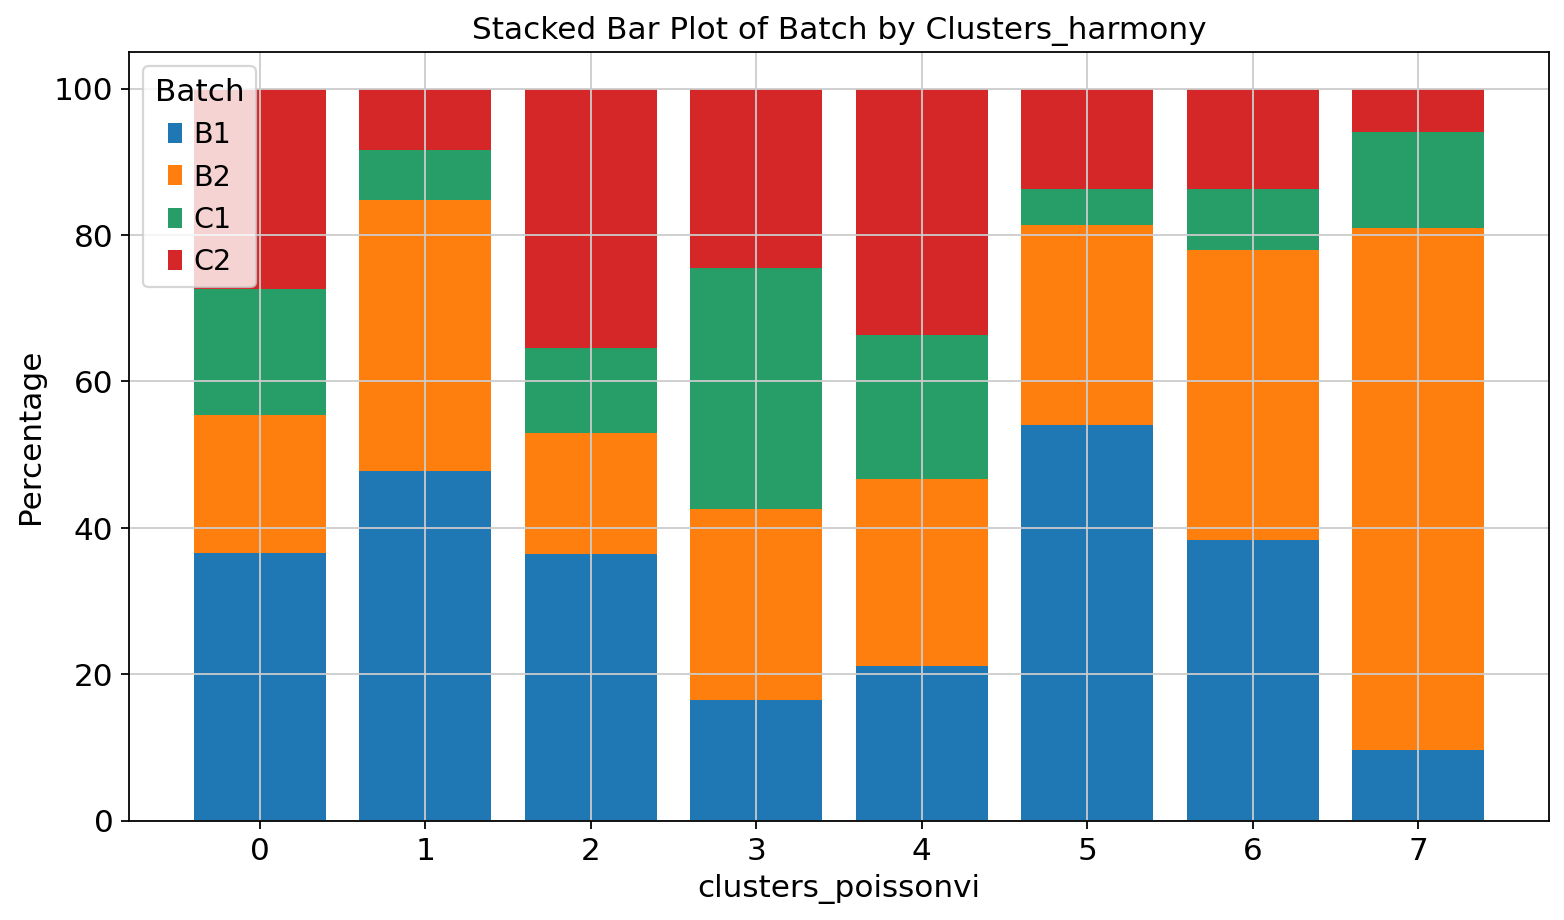

In [116]:
grouped2=adata.obs.groupby(["harmony_cluster","batch"]).size().reset_index(name='count')
df = grouped2
df_pivot = df.pivot_table(values='count', index='batch', columns='harmony_cluster', aggfunc='sum', fill_value=0)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1) * 100

df = df_pivot
# Plotting
plt.figure(figsize=(10, 6))

# Stacked bar plot
bottom = None
for batch in df.index:
    plt.bar(df.columns, df.loc[batch], bottom=bottom, label=batch)
    if bottom is None:
        bottom = df.loc[batch].values
    else:
        bottom += df.loc[batch].values

plt.xlabel('clusters_poissonvi')
plt.ylabel('Percentage')
plt.title('Stacked Bar Plot of Batch by Clusters_harmony')
plt.xticks(df.columns)
plt.legend(title='Batch')
plt.tight_layout()
plt.savefig("../result/intergrate/harmony_integrate.pdf")
plt.show()